In [1]:
!pip install scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 489.4 kB/s  0:00:28m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 719.9 kB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 794.1 kB/s  0:00:40m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-image] [scikit-image]


In [ ]:
# Import the otsu threshold function
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt
from skimage import color
from skimage.filters import sobel

In [1]:
def show_image(image, title='Original'):
  plt.figure()
  plt.imshow(image, cmap='gray')
  plt.title(title)
  plt.axis('off')
  plt.show()
  plt.figure()


## Edge detection

In [5]:
img = plt.imread('image.png')

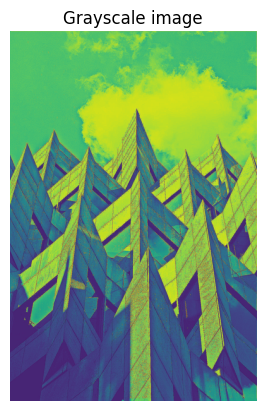

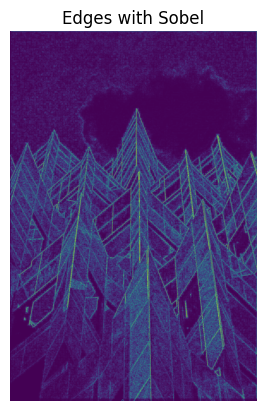

In [ ]:
# Import the color module

img = plt.imread('image.png')

# Make the image grayscale
soaps_image_gray = color.rgb2gray(img)

# Apply edge detection filter
edge_sobel = sobel(soaps_image_gray)

# Show original and resulting image to compare
show_image(soaps_image_gray, "Grayscale image")
show_image(edge_sobel, "Edges with Sobel")

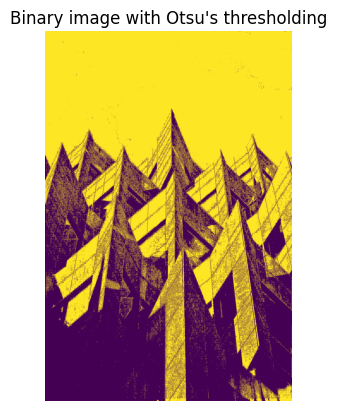

In [ ]:
# Make the image grayscale using rgb2gray
chess_pieces_image_gray = rgb2gray(img)

# Obtain the optimal threshold value with otsu
thresh = threshold_otsu(chess_pieces_image_gray)

# Apply thresholding to the image
binary = chess_pieces_image_gray > thresh

# Show the image
# remove axis
show_image(binary, "Binary image with Otsu's thresholding")

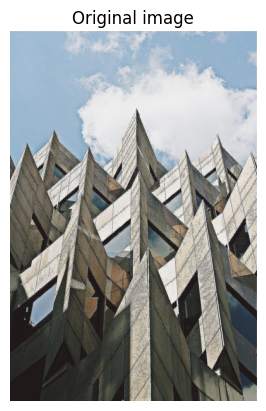

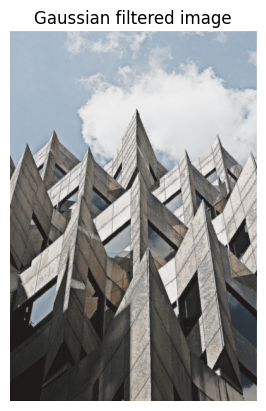

In [ ]:
# Import Gaussian filter 
from skimage.filters import gaussian

# Apply filter
gaussian_image = gaussian(img, sigma=1)

# Show original and resulting image to compare
show_image(img, "Original image")

show_image(gaussian_image, "Gaussian filtered image")

## Contrast enhancement

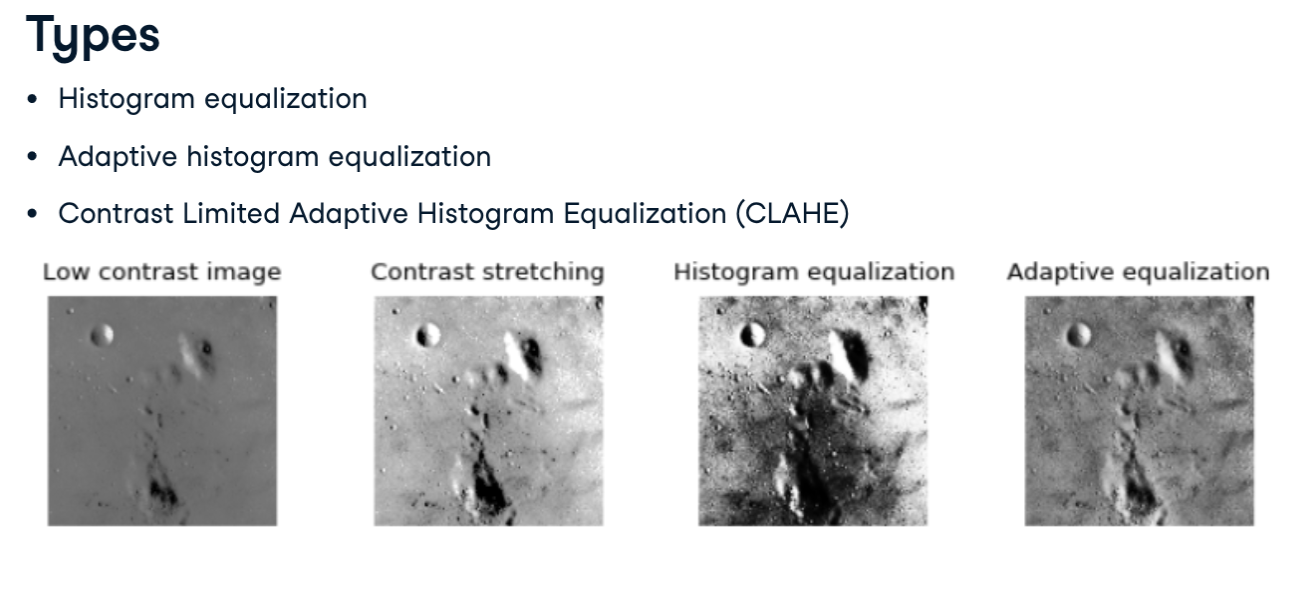

In [16]:
chest_xray_image = plt.imread("chest_xray_image.png")

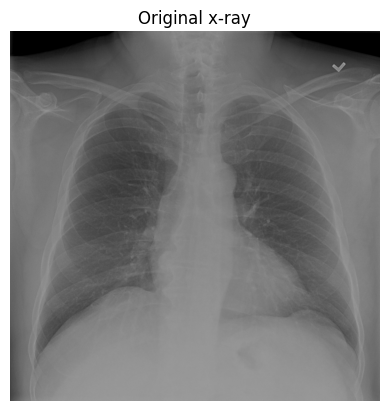

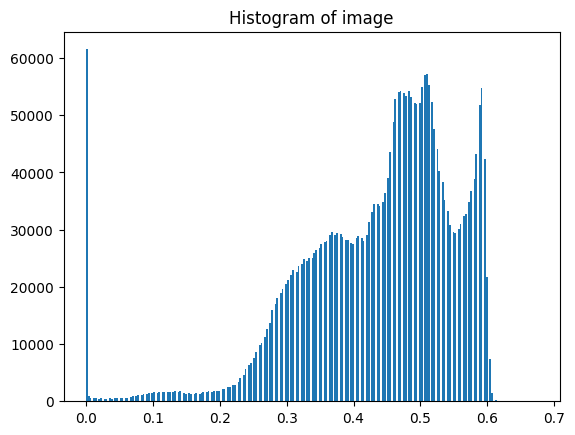

/home/shk/Documents/projects/python/ML/DataCamp/.venv/lib/python3.14/site-packages/skimage/_shared/utils.py:587: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


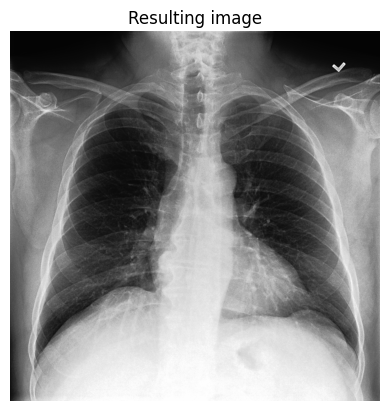

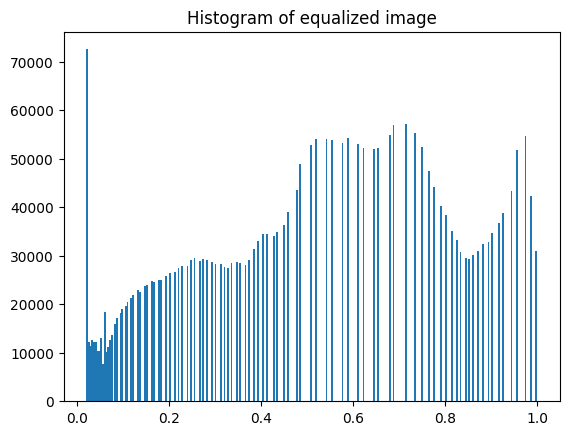

In [18]:
# Import the required module
from skimage import exposure

# Show original x-ray image and its histogram
show_image(chest_xray_image, 'Original x-ray')

plt.title('Histogram of image')
plt.hist(chest_xray_image.ravel(), bins=256)
plt.show()

# Use histogram equalization to improve the contrast
xray_image_eq =  exposure.equalize_hist(chest_xray_image)

# Show the resulting image
show_image(xray_image_eq, 'Resulting image')

plt.title('Histogram of equalized image')
plt.hist(xray_image_eq.ravel(), bins=256)
plt.show()

### Aerial image
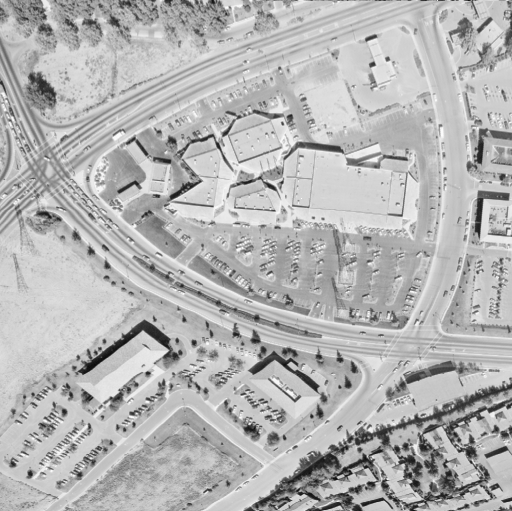


In [19]:
image_aerial = plt.imread("image_aerial.png")

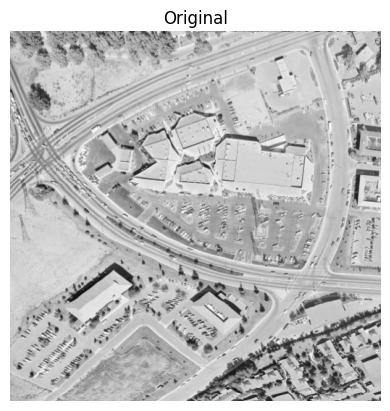

<Figure size 640x480 with 0 Axes>

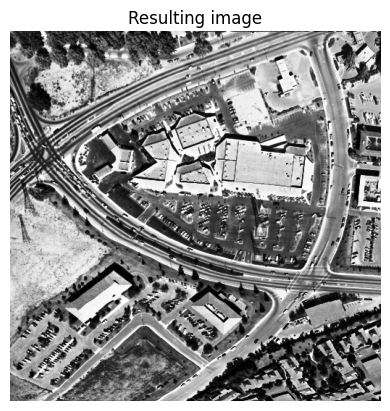

<Figure size 640x480 with 0 Axes>

In [20]:
# Import the required module
from skimage import exposure

# Use histogram equalization to improve the contrast
image_eq =  exposure.equalize_hist(image_aerial)

# Show the original and resulting image
show_image(image_aerial, 'Original')
show_image(image_eq, 'Resulting image')

### Let's add some impact and contrast


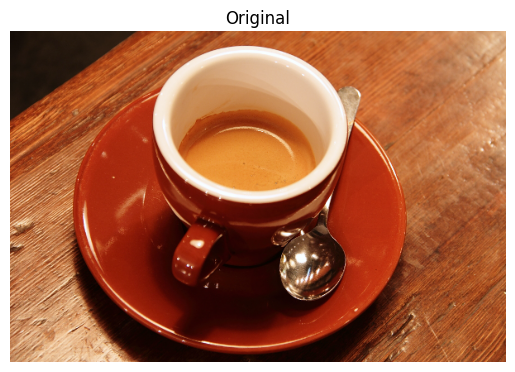

<Figure size 640x480 with 0 Axes>

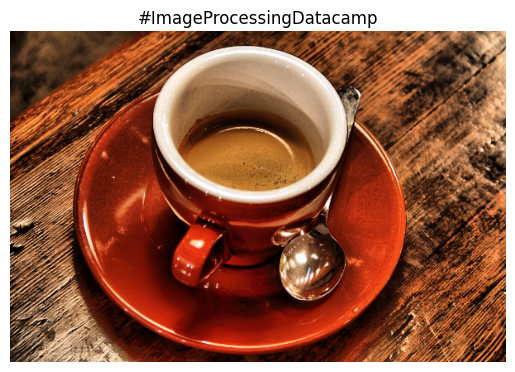

<Figure size 640x480 with 0 Axes>

In [21]:
# Import the necessary modules
from skimage import data, exposure

# Load the image
original_image = data.coffee()

# Apply the adaptive equalization on the original image
adapthist_eq_image = exposure.equalize_adapthist(original_image, clip_limit=0.03)

# Compare the original image to the equalized
show_image(original_image)
show_image(adapthist_eq_image, '#ImageProcessingDatacamp')

## Transformations

In [10]:
import skimage
import matplotlib.pyplot as plt

img = "image_cat.png"
image_cat = plt.imread(img)


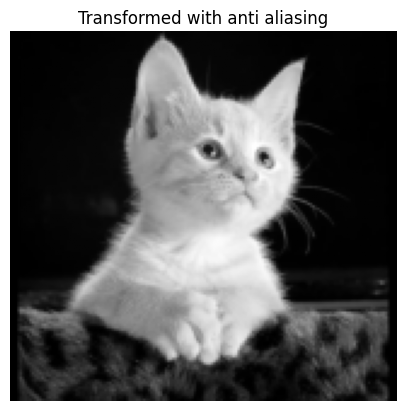

<Figure size 640x480 with 0 Axes>

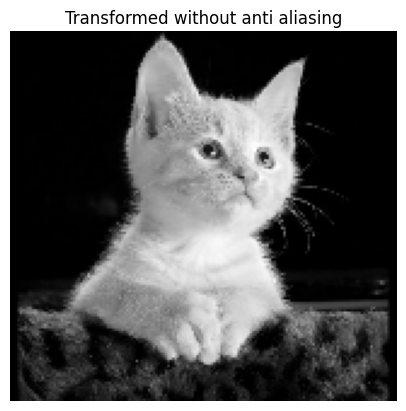

<Figure size 640x480 with 0 Axes>

In [11]:
# Import the module and the rotate and rescale functions
from skimage.transform import rotate, rescale

# Rotate the image 90 degrees clockwise 
rotated_cat_image = rotate(image_cat, -90)

# Rescale with anti aliasing
rescaled_with_aa = rescale(rotated_cat_image, 1/4, anti_aliasing=True)

# Rescale without anti aliasing
rescaled_without_aa = rescale(rotated_cat_image, 1/4, anti_aliasing=False)

# Show the resulting images
show_image(rescaled_with_aa, "Transformed with anti aliasing")
show_image(rescaled_without_aa, "Transformed without anti aliasing")

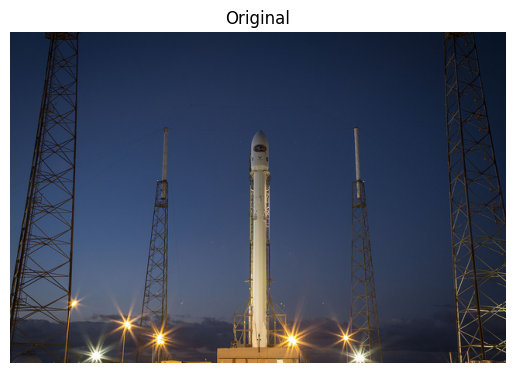

<Figure size 640x480 with 0 Axes>

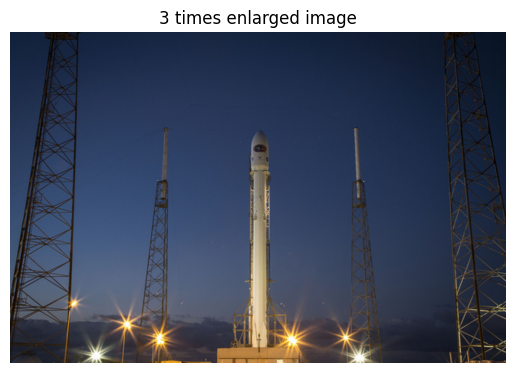

<Figure size 640x480 with 0 Axes>

In [ ]:
# Rescaling (enlarge)

# Import the module and function to enlarge images
from skimage.transform import rescale

# Import the data module
from skimage import data

# Load the image from data
rocket_image = data.rocket()
# Enlarge the image so it is 3 times bigger
enlarged_rocket_image = rescale(
    rocket_image, 3, anti_aliasing=True, channel_axis=-1, preserve_range=True
).astype("uint8")

# Show original and resulting image
show_image(rocket_image)
# Recompute with a proper channel axis so RGB stays 3 channels
show_image(enlarged_rocket_image, "3 times enlarged image")

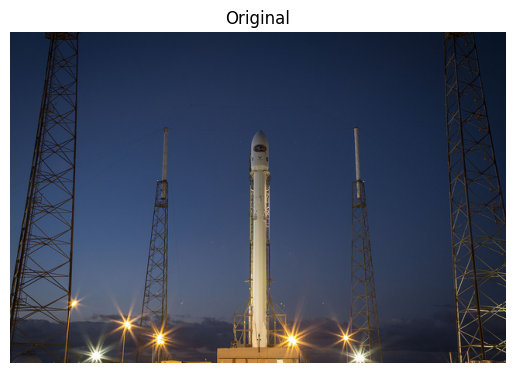

<Figure size 640x480 with 0 Axes>

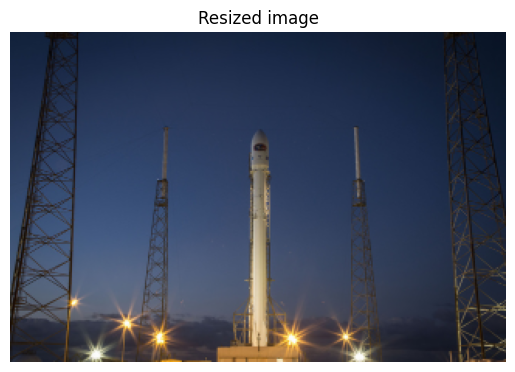

<Figure size 640x480 with 0 Axes>

In [23]:
# resize
# Import the module and function
from skimage.transform import resize

# Set proportional height so its half its size
height = int(rocket_image.shape[0] / 2)
width = int(rocket_image.shape[1] / 2)

# Resize using the calculated proportional height and width
image_resized = resize(rocket_image, (height, width),
                       anti_aliasing=True)

# Show the original and resized image
show_image(rocket_image, 'Original')
show_image(image_resized, 'Resized image')

1. Morphology

    When you try to spot objects in an image, you can do so by its characteristics, like the shape. This what Morphology does.

2. Binary images

    Binary regions produced by simple thresholding can be distorted by noise and texture, as we can see in the image.   

3. Morphological filtering

    Morphological filtering operations try to remove these imperfections by accounting for the form and structure of the objects in the image. These operations are especially suited to binary images, but some can extend to grayscale ones.

4. Morphological operations

    Basic morphological operations are dilation and erosion. Dilation adds pixels to the boundaries of objects in an image, while erosion removes pixels on object boundaries. The number of pixels added or removed from the objects in an image depends on the size and shape of a structuring element used to process the image.

    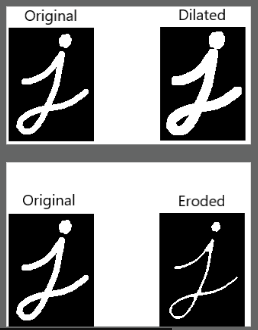

# Image restoration, Noise, Segmentation and Contours

In [ ]:
# Import the module from restoration
from skimage.restoration import inpaint

# Show the defective image
show_image(defect_image, 'Image to restore')

# Apply the restoration function to the image using the mask
restored_image = inpaint.inpaint_biharmonic(defect_image, mask, multichannel=True)
show_image(restored_image)

In [13]:
!pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.restoration import inpaint
import cv2 as cv

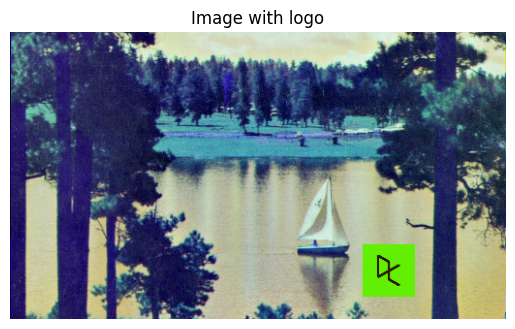

<Figure size 640x480 with 0 Axes>

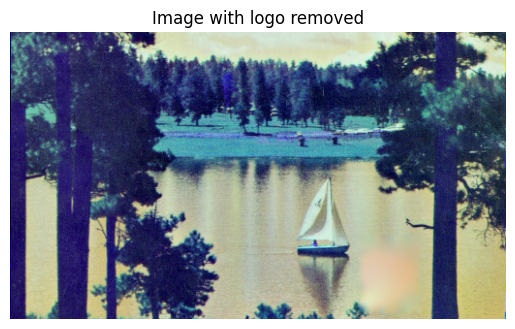

<Figure size 640x480 with 0 Axes>

In [22]:
image_with_logo = cv.imread('image_with_logo.png')
# Initialize the mask
mask = np.zeros(image_with_logo.shape[:-1])
# Set the pixels where the logo is to 1
mask[210:290, 360:425] = 1

# Apply inpainting to remove the logo
image_logo_removed = inpaint.inpaint_biharmonic(
    image_with_logo,
    mask.astype(bool),
    channel_axis=-1
)

# Show the original and logo removed images
show_image(image_with_logo, 'Image with logo')
show_image(image_logo_removed, 'Image with logo removed')